**ANÁLISIS DE ASOSIACIÓN**

In [2]:
import pandas as pd

from mlxtend.preprocessing import TransactionEncoder

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
!pip install mlxtend

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
# ======================================================
# LIBRERÍAS
# ======================================================

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# ======================================================
# CARGAR DATASET
# ======================================================

url = "https://raw.githubusercontent.com/GeorginaLissethJimenezVentura/PARCIAL4_GEORGINA-JIMENEZ_25-3274-2022/refs/heads/main/DATOS/clave_G_asociacion.csv"

df = pd.read_csv(url)

# ======================================================
# SELECCIONAR SOLO COLUMNAS ÚTILES
# ======================================================

datos = df[['transaccion_id', 'item', 'categoria', 'canal']]

print(datos.head())

# ======================================================
# CREAR TRANSACCIONES
# ======================================================

transacciones = []

for id_transaccion, grupo in datos.groupby('transaccion_id'):

    elementos = []

    elementos.extend(grupo['item'].astype(str).tolist())

    elementos.extend(grupo['categoria'].astype(str).tolist())

    elementos.extend(grupo['canal'].astype(str).tolist())

    transacciones.append(elementos)

# ======================================================
# MOSTRAR EJEMPLO DE TRANSACCIONES
# ======================================================

print("\nEJEMPLO DE TRANSACCIONES:")
print(transacciones[:5])

# ======================================================
# CONVERTIR A FORMATO BINARIO
# ======================================================

te = TransactionEncoder()

te_array = te.fit(transacciones).transform(transacciones)

df_binario = pd.DataFrame(te_array, columns=te.columns_)

print("\nDATOS BINARIOS:")
print(df_binario.head())

# ======================================================
# APLICAR APRIORI
# ======================================================

frecuentes = apriori(
    df_binario,
    min_support=0.2,
    use_colnames=True
)

print("\nITEMSETS FRECUENTES:")
print(frecuentes)

# ======================================================
# GENERAR REGLAS
# ======================================================

reglas = association_rules(
    frecuentes,
    metric="confidence",
    min_threshold=0.6
)

# ======================================================
# MOSTRAR REGLAS IMPORTANTES
# ======================================================

resultado = reglas[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].sort_values(by='lift', ascending=False)

print("\nTOP 10 REGLAS MÁS IMPORTANTES:")
print(resultado.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  transaccion_id            item     categoria   canal
0        G-T0001           Arena  Construccion  Tienda
1        G-T0001  Destornillador  Herramientas  Tienda
2        G-T0001            Lija       Pintura  Tienda
3        G-T0002           Cable  Electricidad     App
4        G-T0002     Interruptor  Electricidad     App

EJEMPLO DE TRANSACCIONES:
[['Arena', 'Destornillador', 'Lija', 'Construccion', 'Herramientas', 'Pintura', 'Tienda', 'Tienda', 'Tienda'], ['Cable', 'Interruptor', 'Llave_paso', 'Martillo', 'Tomacorriente', 'Electricidad', 'Electricidad', 'Plomeria', 'Herramientas', 'Electricidad', 'App', 'App', 'App', 'App', 'App'], ['Arena', 'Brocha', 'Rodillo', 'Construccion', 'Pintura', 'Pintura', 'Tienda', 'Tienda', 'Tienda'], ['Llave_paso', 'Taladro', 'Plomeria', 'Herramientas', 'Web', 'Web'], ['Arena', 'Cable', 'Cemento', 'Pegamento_PVC', 'Rodillo', 'Tubo_PVC', 'Cemento', 'Construccion', 'Electricidad', 'Construccion', 'Plomeria', 'Pintura', 'Plomeria', 'Construccion', 'Ap

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   Alicate    App  Arena  Brocha  Cable  Cemento  Clavos   Codo  Construccion  \
0    False  False   True   False  False    False   False  False          True   
1    False   True  False   False   True    False   False  False         False   
2    False  False   True    True  False    False   False  False          True   
3    False  False  False   False  False    False   False  False         False   
4    False   True   True   False   True     True   False  False          True   

   Destornillador  ...  Plomeria  Rodillo  Taladro  Telefono  Tienda  \
0            True  ...     False    False    False     False    True   
1           False  ...      True    False    False     False   False   
2           False  ...     False     True    False     False    True   
3           False  ...      True    False     True     False   False   
4           False  ...      True     True    False     False   False   

   Tomacorriente  Tornillos  Tubo_PVC    Web    nan  
0          False      Fals

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**ANÁLISIS CORRELACIÓN**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

DATASET CARGADO CORRECTAMENTE
  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    G-C0001    36                1333                 12            73.69   
1    G-C0002    38                1318                 11           107.75   
2    G-C0003    40                1105                  9            75.72   
3    G-C0004    34                1349                  6            60.43   
4    G-C0005    52                1073                  2            60.52   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          7.34         1       10             18.10         830.56  
1          8.31         1       10             21.55         998.80  
2          5.89         7        7             17.82         563.19  
3          7.41         1        4             24.88         353.01  
4          6.61         3        0             26.30         143.68  

VARIABLES NUMÉRICAS:
Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', '

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

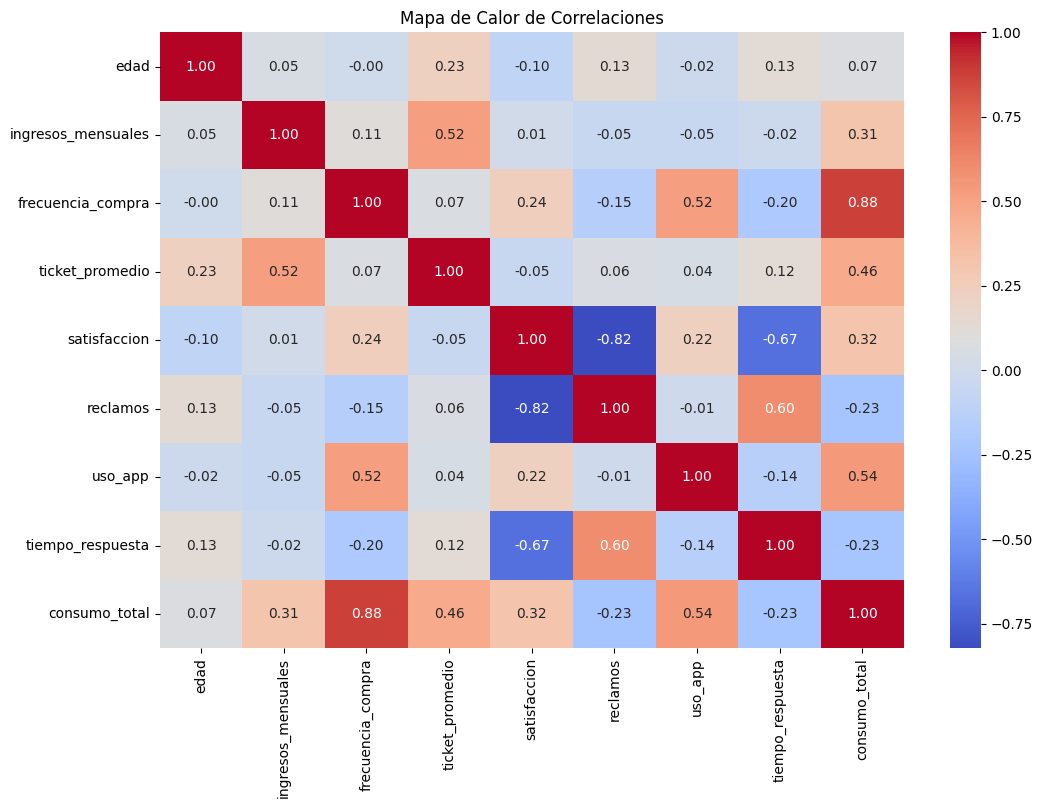


CORRELACIONES POSITIVAS MÁS IMPORTANTES:
frecuencia_compra   consumo_total         0.876545
consumo_total       frecuencia_compra     0.876545
tiempo_respuesta    reclamos              0.600161
reclamos            tiempo_respuesta      0.600161
uso_app             consumo_total         0.543565
consumo_total       uso_app               0.543565
frecuencia_compra   uso_app               0.521483
uso_app             frecuencia_compra     0.521483
ingresos_mensuales  ticket_promedio       0.519953
ticket_promedio     ingresos_mensuales    0.519953
dtype: float64

CORRELACIONES NEGATIVAS MÁS IMPORTANTES:
frecuencia_compra  tiempo_respuesta    -0.200154
tiempo_respuesta   frecuencia_compra   -0.200154
consumo_total      tiempo_respuesta    -0.225117
tiempo_respuesta   consumo_total       -0.225117
consumo_total      reclamos            -0.231863
reclamos           consumo_total       -0.231863
tiempo_respuesta   satisfaccion        -0.668765
satisfaccion       tiempo_respuesta    -0.668765

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
# ============================================================
# 1. CARGAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 2. CARGAR EL ARCHIVO CSV CORRECTAMENTE
# ============================================================

url = "https://raw.githubusercontent.com/GeorginaLissethJimenezVentura/PARCIAL4_GEORGINA-JIMENEZ_25-3274-2022/refs/heads/main/DATOS/clave_G_correlacion.csv"

df = pd.read_csv(url)

print("DATASET CARGADO CORRECTAMENTE")
print(df.head())

# ============================================================
# 3. IDENTIFICAR VARIABLES NUMÉRICAS
# ============================================================

variables_numericas = df.select_dtypes(
    include=['int64', 'float64']
)

print("\nVARIABLES NUMÉRICAS:")
print(variables_numericas.columns)

# ============================================================
# 4. REVISAR DATOS NULOS
# ============================================================

print("\nVALORES NULOS:")
print(df.isnull().sum())

# ============================================================
# 5. REVISAR DUPLICADOS
# ============================================================

print("\nREGISTROS DUPLICADOS:")
print(df.duplicated().sum())

# ============================================================
# 6. REVISAR CONSISTENCIA GENERAL
# ============================================================

print("\nINFORMACIÓN GENERAL:")
print(df.info())

print("\nESTADÍSTICAS DESCRIPTIVAS:")
print(df.describe())

# ============================================================
# 7. DETECTAR VALORES ATÍPICOS
# ============================================================

print("\nVALORES ATÍPICOS:")

for columna in variables_numericas.columns:

    media = df[columna].mean()

    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"\n{columna}: {len(atipicos)} valores atípicos")

# ============================================================
# 8. CALCULAR MATRIZ DE CORRELACIÓN
# ============================================================

matriz_correlacion = variables_numericas.corr()

print("\nMATRIZ DE CORRELACIÓN:")
print(matriz_correlacion)

# ============================================================
# 9. CREAR MAPA DE CALOR
# ============================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Mapa de Calor de Correlaciones")

plt.show()

# ============================================================
# 10. IDENTIFICAR CORRELACIONES POSITIVAS
# ============================================================

print("\nCORRELACIONES POSITIVAS MÁS IMPORTANTES:")

correlaciones = matriz_correlacion.unstack()

correlaciones = correlaciones.sort_values(
    ascending=False
)

correlaciones = correlaciones[
    correlaciones < 1
]

print(correlaciones.head(10))

# ============================================================
# 11. IDENTIFICAR CORRELACIONES NEGATIVAS
# ============================================================

print("\nCORRELACIONES NEGATIVAS MÁS IMPORTANTES:")

print(correlaciones.tail(10))

**CLUSTERING**

DATASET CARGADO CORRECTAMENTE
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     G-R0007    33       631            3.98           15.70          6.07   
1     G-R0123    44       995            6.13           75.82          7.87   
2     G-R0009    28       509            1.30           30.45          5.97   
3     G-R0228    46       769            2.94           69.77          5.28   
4     G-R0106    37      1069            5.56           83.50          8.27   

   reclamos  antiguedad_meses  
0         3                 1  
1         2                32  
2         5                 1  
3        12                21  
4         1                 8  

VALORES NULOS:
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64

VARIABLES SELECCIONADAS:
   ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0

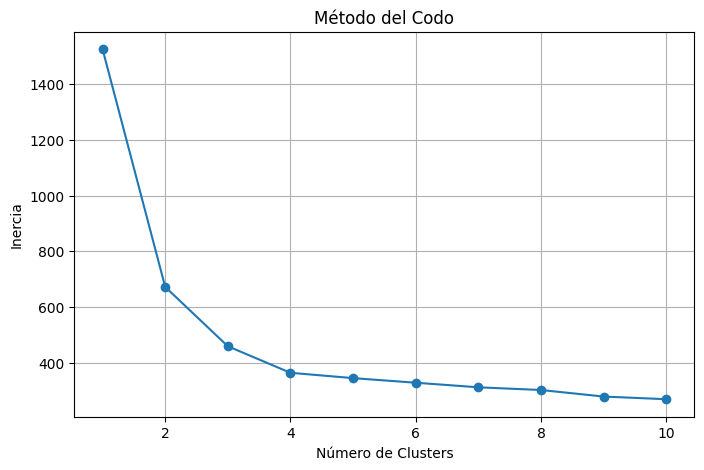


CLUSTERS GENERADOS:
  registro_id  Cluster
0     G-R0007        0
1     G-R0123        1
2     G-R0009        0
3     G-R0228        0
4     G-R0106        1

CANTIDAD DE CLIENTES POR CLUSTER:
Cluster
0    121
1     73
2     60
Name: count, dtype: int64

PROMEDIOS POR CLUSTER:
            ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
Cluster                                                                        
0         769.586777        3.124463       49.111818      5.235041  4.264463   
1        1117.109589        6.616575       87.514795      8.343014  0.904110   
2        1731.666667        9.075500      157.002333      8.972712  0.616667   

         antiguedad_meses  
Cluster                    
0               10.462810  
1               18.219178  
2               38.016667  


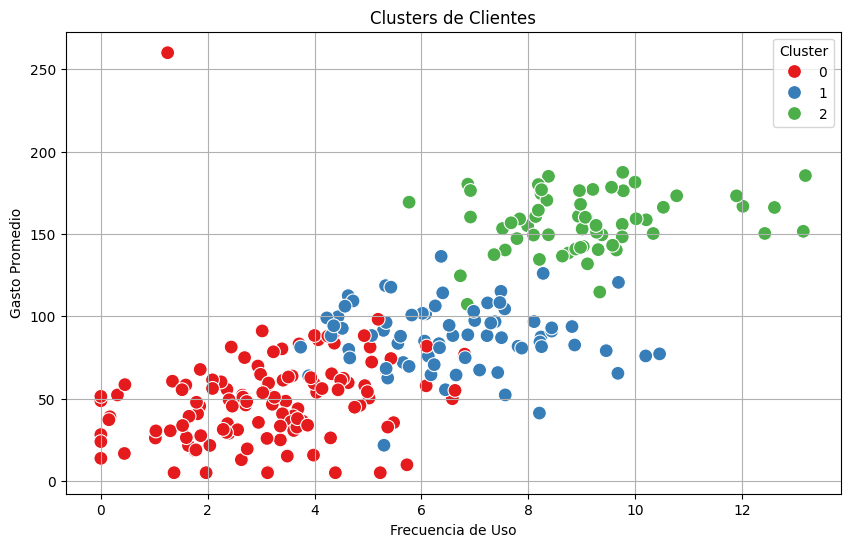


ARCHIVO EXPORTADO CORRECTAMENTE


In [2]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ============================================================
# 2. CARGAR EL DATASET
# ============================================================

url = "https://raw.githubusercontent.com/GeorginaLissethJimenezVentura/PARCIAL4_GEORGINA-JIMENEZ_25-3274-2022/refs/heads/main/DATOS/clave_G_agrupacion.csv"

df = pd.read_csv(url)

print("DATASET CARGADO CORRECTAMENTE")
print(df.head())

# ============================================================
# 3. IDENTIFICAR DATOS NULOS
# ============================================================

print("\nVALORES NULOS:")
print(df.isnull().sum())

# ============================================================
# 4. SELECCIONAR VARIABLES PARA CLUSTERING
# ============================================================

variables_cluster = [
    'ingresos',
    'frecuencia_uso',
    'gasto_promedio',
    'satisfaccion',
    'reclamos',
    'antiguedad_meses'
]

X = df[variables_cluster]

print("\nVARIABLES SELECCIONADAS:")
print(X.head())

# ============================================================
# 5. JUSTIFICACIÓN DE VARIABLES
# ============================================================

print("""
JUSTIFICACIÓN DE VARIABLES:

- ingresos:
  Permite identificar clientes con diferente poder adquisitivo.

- frecuencia_uso:
  Ayuda a detectar clientes activos o inactivos.

- gasto_promedio:
  Permite identificar clientes que generan mayores ingresos.

- satisfaccion:
  Ayuda a detectar clientes satisfechos o en riesgo.

- reclamos:
  Permite analizar problemas en experiencia del cliente.

- antiguedad_meses:
  Ayuda a diferenciar clientes nuevos y antiguos.
""")

# ============================================================
# 6. REEMPLAZAR VALORES NULOS
# ============================================================

X = X.fillna(X.mean())

print("\nVALORES NULOS CORREGIDOS:")
print(X.isnull().sum())

# ============================================================
# 7. NORMALIZAR DATOS
# ============================================================

scaler = StandardScaler()

X_escalado = scaler.fit_transform(X)

print("\nDATOS ESCALADOS CORRECTAMENTE")

# ============================================================
# 8. MÉTODO DEL CODO
# ============================================================

inercias = []

K = range(1, 11)

for k in K:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_escalado)

    inercias.append(modelo.inertia_)

# ============================================================
# 9. GRAFICAR MÉTODO DEL CODO
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(K, inercias, marker='o')

plt.title("Método del Codo")

plt.xlabel("Número de Clusters")

plt.ylabel("Inercia")

plt.grid(True)

plt.show()

# ============================================================
# 10. APLICAR K-MEANS
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_escalado)

print("\nCLUSTERS GENERADOS:")
print(df[['registro_id', 'Cluster']].head())

# ============================================================
# 11. MOSTRAR CANTIDAD DE REGISTROS POR CLUSTER
# ============================================================

print("\nCANTIDAD DE CLIENTES POR CLUSTER:")
print(df['Cluster'].value_counts())

# ============================================================
# 12. CALCULAR PROMEDIOS POR CLUSTER
# ============================================================

centroides = df.groupby('Cluster')[variables_cluster].mean()

print("\nPROMEDIOS POR CLUSTER:")
print(centroides)

# ============================================================
# 13. VISUALIZAR CLUSTERS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='frecuencia_uso',
    y='gasto_promedio',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Clusters de Clientes")

plt.xlabel("Frecuencia de Uso")

plt.ylabel("Gasto Promedio")

plt.grid(True)

plt.show()

# ============================================================
# 14. EXPORTAR RESULTADO
# ============================================================

df.to_csv(
    "resultado_clusters.csv",
    index=False
)

print("\nARCHIVO EXPORTADO CORRECTAMENTE")

